# Module 5 Homework Notebook — NOAA Buoy (Station 44013)  
**Tree methods + margins/kernels + model selection (D–E)**

In this notebook you’ll apply Module 5 Sections **D–E** to the NOAA buoy dataset (station **44013**):

- **D (Tree-based methods):**
  - Decision Trees
  - Random Forests
  - Gradient Boosting
- **E (Margins, kernels, and model selection):**
  - Linear SVM
  - RBF SVM
  - Comparing model families under one evaluation protocol

This notebook is the second NOAA practice notebook and is designed to follow **HW-5-1**, which focused on Sections **A–C**.

---

## What you’ll practice
You will work on two tasks:

### Regression
Predict **significant wave height** (`WVHT`)

### Classification
Predict **wind_high** (high-wind event flag)

Then you will compare model families and answer a professional ML question:

> Which model would I actually deploy, and why?

---

## Important framing
This notebook is not about chasing the highest score.

It is about learning to compare:
- flexibility
- stability
- interpretability
- computational cost
- calibration
- slice robustness


In [57]:
# === Setup ===
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas.api.types import is_numeric_dtype, is_bool_dtype, is_datetime64_any_dtype

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.decomposition import TruncatedSVD
from sklearn.calibration import calibration_curve

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    brier_score_loss, log_loss,
    roc_curve, precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

SEED = 42
rng = np.random.default_rng(SEED)

## 1) Load curated NOAA data (same artifact path as HW-5-1)

This notebook uses the parquet file produced in the NOAA Module 2 homework:

- `~/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet`

We keep the same loading style as HW-5-1 so the workflow stays familiar.


In [58]:
# Path for HW2
HW2_CURATED_PATH = Path("../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet")

# Find file
print(f"Looking for {HW2_CURATED_PATH}")
if HW2_CURATED_PATH.exists():
    print("found")
else:
    print("not-found")

# Load curated data
def load_curated() -> pd.DataFrame:
    print(HW2_CURATED_PATH)
    if HW2_CURATED_PATH.exists():
        df = pd.read_parquet(HW2_CURATED_PATH)
        df["_source"] = "HW2_3.2_curated_parquet"
        return df

    raise FileNotFoundError(
        "Curated data from Module 2 not found"
    )

df = load_curated()
print(f"Loaded: {df["_source"].iloc[0]}")
print(f"Shape: {df.shape}")
df.head(5)

Looking for ../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet
found
../work/HW2_NOAA/data/warehouse/ndbc_curated_44013.parquet
Loaded: HW2_3.2_curated_parquet
Shape: (6563, 23)


,station_id,time_utc,WDIR,WSPD,GST,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,DEWP,VIS,PTDY,TIDE,observation_day,observation_hour,dayofweek,is_weekend,wind_high,temp_gap_c,_source
0,44013,2026-02-15 21:30:00+00:00,90.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.9,-0.9,3.0,-10.8,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
1,44013,2026-02-15 21:20:00+00:00,80.0,2.0,4.0,0.8,6.0,4.6,35.0,1021.7,-0.9,3.0,-10.7,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
2,44013,2026-02-15 21:10:00+00:00,80.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.6,-0.9,3.0,-10.7,NaN,NaN,NaN,2026-02-15,21,6,1,0,-3.9,HW2_3.2_curated_parquet
3,44013,2026-02-15 21:00:00+00:00,80.0,3.0,4.0,NaN,NaN,NaN,NaN,1021.4,-1.0,3.0,-10.6,NaN,0.9,NaN,2026-02-15,21,6,1,0,-4.0,HW2_3.2_curated_parquet
4,44013,2026-02-15 20:50:00+00:00,70.0,3.0,4.0,0.8,6.0,4.5,39.0,1021.2,-0.9,3.0,-10.3,NaN,NaN,NaN,2026-02-15,20,6,1,0,-3.9,HW2_3.2_curated_parquet


## 2) Quick schema + missingness snapshot

Before modeling, confirm:
- column types
- missing-value patterns
- target balance for classification


In [59]:
# Display columns in the dataframe
display(df.dtypes)

# Check for missing columns
required = ["station_id", "time_utc", "observation_day", "observation_hour", "dayofweek", "is_weekend", 
            "wind_high", "temp_gap_c", "WSPD", "GST", "WVHT", "DPD", "APD", "PRES", 
            "ATMP", "WTMP", "WDIR"]

missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

# Missing value summary
missing_summary = pd.DataFrame({
    "pct_missing": (df[required].isna().mean() * 100).round(2)
}).sort_values("pct_missing", ascending=False)
display(missing_summary)

# min max summary
print(f"time_utc min: {df["time_utc"].min()}")
print(f"time_utc max: {df["time_utc"].max()}")
print(f"wind_high rate: {float(df["wind_high"].mean())}")
print(f"WVHT mean: {float(df["WVHT"].mean())}")


station_id                       object
time_utc            datetime64[ns, UTC]
WDIR                            float64
WSPD                            float64
GST                             float64
WVHT                            float64
DPD                             float64
APD                             float64
MWD                             float64
PRES                            float64
ATMP                            float64
WTMP                            float64
DEWP                            float64
VIS                             float64
PTDY                            float64
TIDE                            float64
observation_day                  object
observation_hour                  int32
dayofweek                         int32
is_weekend                        int64
wind_high                         int64
temp_gap_c                      float64
_source                          object
dtype: object

,pct_missing
DPD,66.75
APD,59.33
WVHT,59.33
temp_gap_c,1.45
WTMP,1.34
WDIR,0.58
PRES,0.34
ATMP,0.23
WSPD,0.14
GST,0.14


time_utc min: 2026-01-01 00:00:00+00:00
time_utc max: 2026-02-15 21:30:00+00:00
wind_high rate: 0.1797958250799939
WVHT mean: 1.0737729486699137


## 3) Preprocessing helper (same style as HW-5-1 / Module 5.B–E)

We keep the exact same preprocessing pattern as your earlier notebooks:
- numeric / bool → median impute + standardize
- categoricals → most frequent impute + one-hot encode
- datetimes → dropped by default

This avoids the NaN and dtype issues you’ve seen before.


In [60]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """
    X - feature matrix (input variables)
    y - target vector (predict)

    Uses sklearn Pipeline, ColumnTransformer, SimpleImputer, StandardScaler, OneHotEncoder
    Uses pandas api types
    """

    # Sort columns into three buckets by dtype
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]

    # Numerical pipeline: fill missing with median, then standardize
    num_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    # Categorical pipeline: fill missing with most frequent, then one-hot encode
    cat_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    # Combine into a single transformer. DateTime columns are droped via remainder=drop
    pre = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre
    

def describe_cols(X: pd.DataFrame) -> tuple[list[str], list[str], list[str]]:
    """
    Inspect columns without running full pre-processor
    Uses pandas api types
    """
    # Sort columns into three buckets by dtype
    num_cols = [c for c in X.columns if is_numeric_dtype(X[c]) or is_bool_dtype(X[c])]
    dt_cols = [c for c in X.columns if is_datetime64_any_dtype(X[c])]
    cat_cols = [c for c in X.columns if (c not in num_cols) and (c not in dt_cols)]
    return num_cols, cat_cols, dt_cols

print("Preprocessor functions ready")

Preprocessor functions ready


## 4) Shared split helper (same protocol as HW-5-1)

We use a random split:
- train: 70%
- validation: 15%
- test: 15%

For classification we stratify by the label.


In [61]:
def split_random(
    X: pd.DataFrame,
    y: pd.Series,
    stratify: pd.Series | None=None,
    seed: int=SEED,
    train: float=0.70,
    val: float=0.15,
    test: float=0.15,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """
    Split X and y into train, validation and test sets
    Uses sklearn train_test_split()
    """

    # Ensure the three proportions sum to 1.0
    assert abs(train + val + test - 1.0) < 1e-9

    # First split: carve out training set, remainder = val + test
    Xtr, Xtmp, ytr, ytmp = train_test_split(X, y, test_size=(1 - train), random_state=seed, stratify=stratify)

    # Compute remainder fraction
    val_frac_of_tmp = val / (val + test)

    # Second split: divide into val and test
    Xva, Xte, yva, yte = train_test_split(Xtmp, ytmp, test_size=(1 - val_frac_of_tmp), random_state=seed, stratify=(ytmp if stratify is not None else None))

    return Xtr, Xva, Xte, ytr, yva, yte


print("Split function ready")

Split function ready


## 5) Shared metric helpers

We’ll use the same reporting pattern throughout.


In [62]:
# === Regression metrics ===
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

def regression_report(y_true, yhat, label=""):
    """
    Compute a standard set of regression metrics.
    Includes tail-risk metrics (p90, p95) because RMSE alone can hide poor performance on outliers
    """
    abs_err = np.abs(y_true - yhat)
    return {
        "label": label,
        "MAE": float(mean_absolute_error(y_true, yhat)),
        "RMSE": rmse(y_true, yhat),
        "R2": float(r2_score(y_true, yhat)),
        "MedianAbsErr": float(np.median(abs_err)),
        "P90AbsErr": float(np.quantile(abs_err, 0.90)),
        "P95AbsErr": float(np.quantile(abs_err, 0.95)),
    }

# === Classification metrics ===
def eval_probs(y_true, p, threshold=0.5, label=""):
    """
    Compute two types of metrics

    - Threshold based: accuracy, precision, recall, F1
    - Threshold free: ROC-AUC, average precision, Brier score, log-loss
    """
    yhat = (p >= threshold).astype(int)
    out = {
        "label": label,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, yhat)),
        "precision": float(precision_score(y_true, yhat, zero_division=0)),
        "recall": float(recall_score(y_true, yhat, zero_division=0)),
        "f1": float(f1_score(y_true, yhat, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["avg_precision"] = float(average_precision_score(y_true, p))
    except Exception:
        out["avg_precision"] = float("nan")
    try:
        out["brier"] = float(brier_score_loss(y_true, p))
    except Exception:
        out["brier"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, p, labels=[0,1]))
    except Exception:
        out["log_loss"] = float("nan")
    return out

def threshold_sweep(y_true, p, thresholds=None):
    """
    Evaluate eval_probs across a range of thresholds

    Useful for finding the threshold that maximises F1 or satisfies a precision/recall trade-off
    """
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 37)
    return pd.DataFrame([
        eval_probs(y_true, p, threshold=float(t))
        for t in thresholds
    ])

def confusion_counts(y_true, p, t):
    """
    Compute true negative, false positive, false negative, true positive
    """
    yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat).ravel()
    return int(tp), int(fp), int(tn), int(fn)

def per_1000_counts(tp, fp, tn, fn):
    """
    Rescale confusion matrix

    Makes error rates easier to interpret in operational terms 
    "we miss 14 high-wind events per 1000 observations"
    """
    n = tp + fp + tn + fn
    scale = 1000.0 / n if n > 0 else 0.0
    return {
        "TP_per_1000": tp * scale,
        "FP_per_1000": fp * scale,
        "TN_per_1000": tn * scale,
        "FN_per_1000": fn * scale,
    }

def report_with_counts(y_true, p, t, label):
    """
    Combin eval_probs with raw and per-1000 confusion matrix counts
    """
    rep = eval_probs(y_true, p, threshold=t, label=label)
    tp, fp, tn, fn = confusion_counts(y_true, p, t)
    rep.update({"TP": tp, "FP": fp, "TN": tn, "FN": fn})
    rep.update(per_1000_counts(tp, fp, tn, fn))
    return rep

print("Shared Metric Functions Ready")

Shared Metric Functions Ready


# Part D — Tree-based methods (Regression)

We’ll keep the same regression target from HW-5-1:

> **Target:** `WVHT`

We will compare:
- mean predictor
- linear regression baseline
- decision tree regressor
- random forest regressor
- gradient boosting regressor


### Leakage Check

Before building any model we need to confirm that no features in `X_reg` 
would be unavailable at prediction time, or would directly encode the target.

**Dropped outright:**
- `WVHT` - the target itself
- `station_id`, `_source`, `observation_day`, `time_utc` - identifiers, not signals
- `DEWP`, `PTDY`, `TIDE`, `VIS` - sparse / unreliable columns dropped in HW2 curation
- `wind_high` - a derived label that is partly a function of wave conditions;
  keeping it would let the model "cheat" by reading a summary of the outcome

**Retained but worth watching:**
- `WSPD`, `GST` (wind speed / gust) - physically upstream of wave height,
  so they are legitimate predictors, not leakage. Wind drives waves.
- `APD`, `DPD` (wave period) - also physically upstream. Longer-period swells
  precede and accompany larger waves, so these are causal features, not leakage.

In [63]:
# Choose regression target and features
TARGET_REG = "WVHT"

# Drop columns that are either identifiers or not features
DROP_ALWAYS = {"WVHT", "station_id", "_source", "DEWP", "PTDY", "TIDE", "VIS", "observation_day"}

# Drop raw datetime
DROP_ALWAYS |= {"time_utc"}

# Drop target "cousins" (High Wind is usually associated with waveheight and can cause leakage)
DROP_ALWAYS |= {"wind_high"}

# Build feature table
y_reg = df[TARGET_REG].astype(float).to_numpy()
X_reg = df.drop(columns=[c for c in DROP_ALWAYS if c in df.columns]).copy()

# Drop rows where target is NaN
mask = ~np.isnan(y_reg)
y_reg = y_reg[mask]
X_reg = X_reg[mask]

# Output
print(f"Regression (X_reg) rows: {X_reg.shape[0]}")
print(f"Regression (X_reg) feature count: {X_reg.shape[1]}")
X_reg.head(3)

Regression (X_reg) rows: 2669
Regression (X_reg) feature count: 13


,WDIR,WSPD,GST,DPD,APD,MWD,PRES,ATMP,WTMP,observation_hour,dayofweek,is_weekend,temp_gap_c
1,80.0,2.0,4.0,6.0,4.6,35.0,1021.7,-0.9,3.0,21,6,1,-3.9
4,70.0,3.0,4.0,6.0,4.5,39.0,1021.2,-0.9,3.0,20,6,1,-3.9
7,60.0,3.0,5.0,5.0,4.4,32.0,1021.0,-1.2,3.0,20,6,1,-4.2


In [64]:
# Random Split
Xtr_r, Xva_r, Xte_r, ytr_r, yva_r, yte_r = split_random(X_reg, y_reg, stratify=None)

print(f"Split sizes: {len(ytr_r)}, {len(yva_r)}, {len(yte_r)}")
print(f"Target mean (train/val/test): {float(np.mean(ytr_r))}, {float(np.mean(yva_r))}, {float(np.mean(yte_r))}")

Split sizes: 1868, 400, 401
Target mean (train/val/test): 1.0626873661670235, 1.1127500000000001, 1.0865336658354117


In [65]:
# Build preprocessor
pre_r = build_preprocessor(Xtr_r)
num_r, cat_r, dt_r = describe_cols(Xtr_r)
print("Regression columns:", len(num_r), "numeric |", len(cat_r), "categorical |", len(dt_r), "datetime dropped")

Regression columns: 13 numeric | 0 categorical | 0 datetime dropped


## D.1 Baselines for regression

### Comparators
* **RMSE:** squares errors and takes the mean - large errors are penalized more (*lower is better*)
* **MAE:** average absolute error - how much the predictions are off by (*lower is better*)
* **R$^2$:** proportion of variance, 0=mean, 1=perfect (*higher is better*)
* **MedianAbsErr:** middle value of all absolute errors, ignores outliers (*lower is better*)
* **p90AbsErr:** 90% of the predictions are within this error. Other 10% are worse (*lower is better*)
* **p95AbsErr:** 95% of the predictions are within this error. Other 5% are worse (*lower is better*)

In [66]:
# Mean predictor - simplist possible model (sets the floor)
y_mean = float(np.mean(ytr_r))
yhat_mean = np.full_like(yte_r, y_mean)
base_mean = regression_report(yte_r, yhat_mean, label="mean_predictor_test")

# Linear baseline - another simple model, a tree model should be able to beat it
linreg = Pipeline([("pre", pre_r), ("model", LinearRegression())])
t0 = time.time()
linreg.fit(Xtr_r, ytr_r)
linreg_fit_sec = time.time() - t0

yhat_lin = linreg.predict(Xte_r)
base_lin = regression_report(yte_r, yhat_lin, label="linear_regression_test")
base_lin["fit_seconds"] = linreg_fit_sec

# Display combined
pd.DataFrame([base_mean, base_lin]).sort_values("RMSE")

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,fit_seconds
1,linear_regression_test,0.190157,0.286952,0.853071,0.136575,0.396381,0.510416,0.004857
0,mean_predictor_test,0.497164,0.748990,-0.001015,0.362687,0.937313,1.537313,NaN


## D.2 Tree regressors — validation search
Do a validation search across Decision Trees, Random Forests, and Gradient Boosting

In [67]:
# Setup
reg_results = []
reg_models = {}

In [68]:
# Decision Tree Regressor
for depth in [3, 5, 8, 12]:
    pipe = Pipeline([
        ("pre", pre_r),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ])
    t0 = time.time()
    pipe.fit(Xtr_r, ytr_r)
    fit_sec = time.time() - t0

    rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"dtr_depth_{depth}_val")
    rep["family"] = "DecisionTreeRegressor"
    rep["fit_seconds"] = fit_sec
    rep["max_depth"] = depth
    reg_results.append(rep)
    reg_models[rep["label"]] = pipe

In [69]:
# Random Forest Regressor
for n_est in [150, 300]:
    for depth in [None, 8, 12]:
        pipe = Pipeline([
            ("pre", pre_r),
            ("model", RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        pipe.fit(Xtr_r, ytr_r)
        fit_sec = time.time() - t0

        rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"rfr_n{n_est}_d{depth}_val")
        rep["family"] = "RandomForestRegressor"
        rep["fit_seconds"] = fit_sec
        rep["n_estimators"] = n_est
        rep["max_depth"] = depth
        reg_results.append(rep)
        reg_models[rep["label"]] = pipe

In [70]:
# Gradient Boosting Regressor
for lr in [0.03, 0.08]:
    for n_est in [120, 250]:
        pipe = Pipeline([
            ("pre", pre_r),
            ("model", GradientBoostingRegressor(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=3,
                subsample=0.8,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        pipe.fit(Xtr_r, ytr_r)
        fit_sec = time.time() - t0

        rep = regression_report(yva_r, pipe.predict(Xva_r), label=f"gbr_lr{lr}_n{n_est}_val")
        rep["family"] = "GradientBoostingRegressor"
        rep["fit_seconds"] = fit_sec
        rep["learning_rate"] = lr
        rep["n_estimators"] = n_est
        reg_results.append(rep)
        reg_models[rep["label"]] = pipe

In [71]:
# Comparison of models
reg_val = pd.DataFrame(reg_results).sort_values(["RMSE", "MAE"])
display(reg_val.head(12))

,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,family,fit_seconds,max_depth,n_estimators,learning_rate
13,gbr_lr0.08_n250_val,0.082981,0.140454,0.966954,0.056454,0.167527,0.224387,GradientBoostingRegressor,0.417392,NaN,250.0,0.08
6,rfr_n150_d12_val,0.080938,0.149053,0.962784,0.050992,0.159907,0.232640,RandomForestRegressor,0.139179,12.0,150.0,NaN
4,rfr_n150_dNone_val,0.080896,0.149247,0.962687,0.050978,0.158182,0.233434,RandomForestRegressor,0.137775,NaN,150.0,NaN
9,rfr_n300_d12_val,0.081137,0.149818,0.962400,0.050565,0.163507,0.241728,RandomForestRegressor,0.260418,12.0,300.0,NaN
7,rfr_n300_dNone_val,0.081002,0.150054,0.962282,0.050079,0.165547,0.241363,RandomForestRegressor,0.253186,NaN,300.0,NaN
12,gbr_lr0.08_n120_val,0.092031,0.150159,0.962229,0.060718,0.188410,0.254123,GradientBoostingRegressor,0.201113,NaN,120.0,0.08
5,rfr_n150_d8_val,0.089825,0.155752,0.959363,0.057254,0.184258,0.276448,RandomForestRegressor,0.126494,8.0,150.0,NaN
8,rfr_n300_d8_val,0.089853,0.156075,0.959194,0.057062,0.185634,0.279314,RandomForestRegressor,0.254675,8.0,300.0,NaN
11,gbr_lr0.03_n250_val,0.095262,0.157301,0.958551,0.060380,0.196705,0.266418,GradientBoostingRegressor,0.417388,NaN,250.0,0.03
10,gbr_lr0.03_n120_val,0.112517,0.177108,0.947455,0.079277,0.224726,0.313287,GradientBoostingRegressor,0.206462,NaN,120.0,0.03


In [72]:
# Best Regression Tree Model
best_reg_row = reg_val.iloc[0]
best_reg_label = best_reg_row["label"]
best_reg_model = reg_models[best_reg_label]

print("Best regression tree model on validation:")
display(best_reg_row.to_frame().T)

yhat_best_reg = best_reg_model.predict(Xte_r)
best_reg_test = regression_report(yte_r, yhat_best_reg, label=best_reg_label.replace("_val", "_test"))
best_reg_test["fit_seconds"] = float(best_reg_row["fit_seconds"])

print("\nCompared to baseline models:")
pd.DataFrame([base_mean, base_lin, best_reg_test]).sort_values("RMSE")

Best regression tree model on validation:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,family,fit_seconds,max_depth,n_estimators,learning_rate
13,gbr_lr0.08_n250_val,0.082981,0.140454,0.966954,0.056454,0.167527,0.224387,GradientBoostingRegressor,0.417392,NaN,250.0,0.08



Compared to baseline models:


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,fit_seconds
2,gbr_lr0.08_n250_test,0.075509,0.099011,0.982507,0.063199,0.164401,0.208428,0.417392
1,linear_regression_test,0.190157,0.286952,0.853071,0.136575,0.396381,0.510416,0.004857
0,mean_predictor_test,0.497164,0.748990,-0.001015,0.362687,0.937313,1.537313,NaN


## D.3 Regression diagnostics: residuals + tail risk

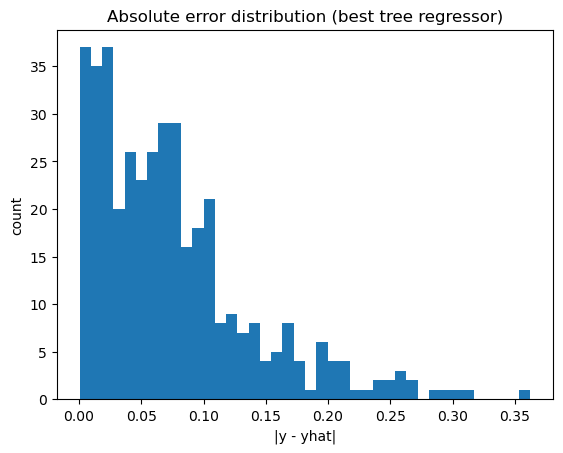

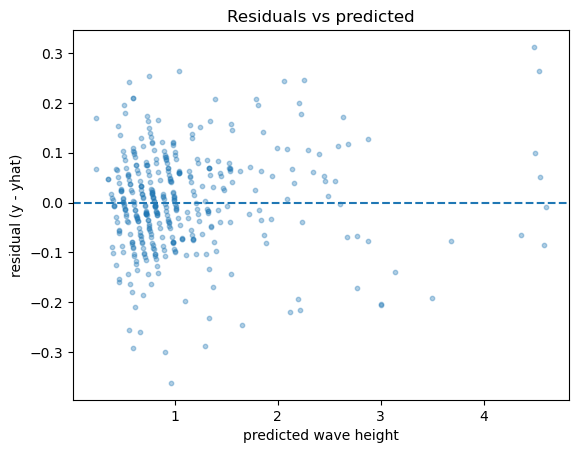

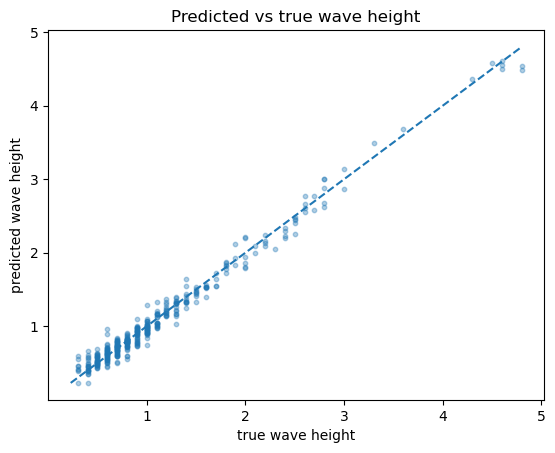

Median abs error: 0.06319897926471207
P90 abs error: 0.16440090548068476
P95 abs error: 0.20842793690022687


In [73]:
resid = yte_r - yhat_best_reg
abs_err = np.abs(resid)

plt.figure()
plt.hist(abs_err, bins=40)
plt.title("Absolute error distribution (best tree regressor)")
plt.xlabel("|y - yhat|")
plt.ylabel("count")
plt.show()

plt.figure()
plt.scatter(yhat_best_reg, resid, s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs predicted")
plt.xlabel("predicted wave height")
plt.ylabel("residual (y - yhat)")
plt.show()

plt.figure()
plt.scatter(yte_r, yhat_best_reg, s=10, alpha=0.35)
mn = float(min(yte_r.min(), yhat_best_reg.min()))
mx = float(max(yte_r.max(), yhat_best_reg.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Predicted vs true wave height")
plt.xlabel("true wave height")
plt.ylabel("predicted wave height")
plt.show()

print("Median abs error:", float(np.median(abs_err)))
print("P90 abs error:", float(np.quantile(abs_err, 0.90)))
print("P95 abs error:", float(np.quantile(abs_err, 0.95)))


 ### Analysis

 * **Absolute error distribution** - this shows a heavy concentration near zero, with most errors under 0.1 meters. There is a right-skew, but drops off quickly. No errors above ~0.40 meters.
 * **Residuals vs predicted** - shows a clean pattern. At low predicted values (~1) the points are clustered and well centered around zero. The model is accurate for calmish sea conditions. The spread increases slightly at higher predicted values (>2). The model is slightly less accurate for larger waves.
 * **Predicted vs true** - The points track the diagonal tightly, confirming strong overall fit. 

This is a well performing model, but has weaknesses at the extremes.
 

## D.4 Slice analysis by wind regime

To see where the regressor struggles, slice the test set by wind direction (`WDIR`) quartiles.


In [74]:
df_test_reg = df.loc[Xte_r.index].copy()
df_test_reg["y_true"] = yte_r
df_test_reg["y_pred"] = yhat_best_reg
df_test_reg["abs_err"] = np.abs(df_test_reg["y_true"] - df_test_reg["y_pred"])
df_test_reg["sq_err"] = (df_test_reg["y_true"] - df_test_reg["y_pred"])**2

def group_reg_metrics(df_g):
    return pd.Series({
        "n": len(df_g),
        "MAE": float(df_g["abs_err"].mean()),
        "RMSE": float(np.sqrt(df_g["sq_err"].mean())),
        "P90AbsErr": float(np.quantile(df_g["abs_err"], 0.90)),
    })

df_test_reg["WDIR_bin"] = pd.cut(df_test_reg["WDIR"], bins=[0, 220, 260, 280, 360])
wdir_slice = df_test_reg.groupby("WDIR_bin").apply(group_reg_metrics).sort_values("RMSE", ascending=False)
display(wdir_slice)

,n,MAE,RMSE,P90AbsErr
WDIR_bin,,,,
"(0, 220]",107.0,0.080378,0.106488,0.173283
"(280, 360]",170.0,0.082268,0.104252,0.172323
"(220, 260]",64.0,0.064395,0.085245,0.142688
"(260, 280]",58.0,0.060423,0.083236,0.132248


### Analysis
Performance is broadly consistent across wind-direction quartiles. RMSE stays within a tight range. However, the bins have unequal row counts. The larger bins may benefit from a more representative test sample. 

## D.5 Tree regressor feature importance

In [75]:
best_reg_core = best_reg_model.named_steps["model"]
best_reg_pre = best_reg_model.named_steps["pre"]
reg_feature_names = list(best_reg_pre.get_feature_names_out())

if hasattr(best_reg_core, "feature_importances_"):
    reg_imp = pd.DataFrame({
        "feature": reg_feature_names,
        "importance": best_reg_core.feature_importances_
    }).sort_values("importance", ascending=False)
    display(reg_imp.head(20))
else:
    print("This regression model does not expose feature_importances_.")

,feature,importance
4,APD,0.547390
1,WSPD,0.193732
2,GST,0.122966
6,PRES,0.039169
8,WTMP,0.027723
0,WDIR,0.023663
10,dayofweek,0.018239
7,ATMP,0.010853
12,temp_gap_c,0.009596
5,MWD,0.002548


### Analysis
Average wave period (APD) is by far the most important feature. This is physically intuitive, longer period swells carry more energy and can tend to produce greater wave heights. Period seems to be a more stable indicator of sea state than instantaneous wind speed, possibly because it reflects accumulated energy and not just current conditions. 

Wind Speed (WSPD) and gusts (GST) rank next. This is expected as wind is a primary forcing mechanism for wave generation. The interesting observation is that wind speed is below wave period.
 

# Part E — Margins, kernels, and model selection (Classification)

We keep the same classification label as HW-5-1:

> **Target:** `wind_high`

But we deliberately drop likely direct revealers:
- `WSPD`
- `GST`

That forces the models to learn from the rest of the buoy context rather than “cheating” with the direct wind measures.


In [76]:
# Feature matrix and target
TARGET_CLF = "wind_high"

DROP_CLF = {"wind_high", "station_id", "_source", "DEWP", "PTDY", "TIDE", "VIS", 
            "observation_day", "time_utc", "WSPD", "GST"}

y_clf = df[TARGET_CLF].astype(int).to_numpy()
X_clf = df.drop(columns=[c for c in DROP_CLF if c in df.columns]).copy()

# Drop rows where target is NaN
mask = ~np.isnan(y_clf)
y_clf = y_clf[mask]
X_clf = X_clf[mask]

print(f"Classification (X_clf) rows: {X_clf.shape[0]}")
print(f"Classification (X_clf) feature count: {X_clf.shape[1]}")
print(f"wind_high positive rate: {float(y_clf.mean()):.3f}")

Classification (X_clf) rows: 6563
Classification (X_clf) feature count: 12
wind_high positive rate: 0.180


In [77]:
# Stratified split
Xtr_c, Xva_c, Xte_c, ytr_c, yva_c, yte_c = split_random(X_clf, y_clf, stratify=y_clf)
print(f"Split sizes: {len(ytr_c)}, {len(yva_c)}, {len(yte_c)}")
print(f"Positive rates (train/val/test): {float(ytr_c.mean()):.3f}, {float(yva_c.mean()):.3f}, {float(yte_c.mean()):.3f}")


Split sizes: 4594, 984, 985
Positive rates (train/val/test): 0.180, 0.180, 0.180


In [78]:
# Preprocessor
pre_c = build_preprocessor(Xtr_c)
num_c, cat_c, dt_c = describe_cols(Xtr_c)
print("Classification columns:", len(num_c), "numeric |", len(cat_c), "categorical |", len(dt_c), "datetime dropped")


Classification columns: 12 numeric | 0 categorical | 0 datetime dropped


In [79]:
print(f"Rows: {X_clf.shape[0]}")
print(f"Positive rate: {float(y_clf.mean())}")
display(X_clf.head(3))

Rows: 6563
Positive rate: 0.1797958250799939


,WDIR,WVHT,DPD,APD,MWD,PRES,ATMP,WTMP,observation_hour,dayofweek,is_weekend,temp_gap_c
0,90.0,NaN,NaN,NaN,NaN,1021.9,-0.9,3.0,21,6,1,-3.9
1,80.0,0.8,6.0,4.6,35.0,1021.7,-0.9,3.0,21,6,1,-3.9
2,80.0,NaN,NaN,NaN,NaN,1021.6,-0.9,3.0,21,6,1,-3.9


## E.1 Baselines: majority predictor + logistic regression

In [80]:
# Majority Baseline
majority_class = int(np.mean(ytr_c) >= 0.5)
yhat_majority = np.full_like(yte_c, majority_class)

base_majority = {
    "label": "majority_predictor_test",
    "threshold": None,
    "accuracy": float(accuracy_score(yte_c, yhat_majority)),
    "precision": float(precision_score(yte_c, yhat_majority, zero_division=0)),
    "recall": float(recall_score(yte_c, yhat_majority, zero_division=0)),
    "f1": float(f1_score(yte_c, yhat_majority, zero_division=0)),
}


In [81]:
# Logistic Baseline
logreg = Pipeline([
    ("pre", pre_c),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"))
])

t0 = time.time()
logreg.fit(Xtr_c, ytr_c)
fit_logreg = time.time() - t0

p_va_log = logreg.predict_proba(Xva_c)[:,1]
log_val = eval_probs(yva_c, p_va_log, threshold=0.5, label="logreg_val")
log_val["family"] = "LogisticRegression"
log_val["fit_seconds"] = fit_logreg


In [82]:
display(pd.DataFrame([base_majority]))
display(pd.DataFrame([log_val]))

,label,threshold,accuracy,precision,recall,f1
0,majority_predictor_test,None,0.820305,0.0,0.0,0.0


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds
0,logreg_val,0.5,0.778455,0.434921,0.774011,0.556911,0.870582,0.583506,0.149094,0.461406,LogisticRegression,0.018259


## E.2 Tree classifiers on the same task
Do a validation search across Decision Trees, Random Forests, and Gradient Boosting

In [83]:
# Setup
clf_results = []
clf_models = {}

In [84]:
# Decision Tree
for depth in [3, 5, 8, 12]:
    pipe = Pipeline([
        ("pre", pre_c),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=10,
            random_state=SEED
        ))
    ])
    t0 = time.time()
    pipe.fit(Xtr_c, ytr_c)
    fit_sec = time.time() - t0

    p_va = pipe.predict_proba(Xva_c)[:,1]
    rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"dtc_depth_{depth}_val")
    rep["family"] = "DecisionTreeClassifier"
    rep["fit_seconds"] = fit_sec
    rep["max_depth"] = depth
    clf_results.append(rep)
    clf_models[rep["label"]] = pipe

In [85]:
# Random Forest
for n_est in [150, 300]:
    for depth in [None, 10]:
        pipe = Pipeline([
            ("pre", pre_c),
            ("model", RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=5,
                n_jobs=-1,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        pipe.fit(Xtr_c, ytr_c)
        fit_sec = time.time() - t0

        p_va = pipe.predict_proba(Xva_c)[:,1]
        rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"rfc_n{n_est}_d{depth}_val")
        rep["family"] = "RandomForestClassifier"
        rep["fit_seconds"] = fit_sec
        rep["n_estimators"] = n_est
        rep["max_depth"] = depth
        clf_results.append(rep)
        clf_models[rep["label"]] = pipe


In [86]:
# Gradient Boosting
for lr in [0.03, 0.08]:
    for n_est in [120, 250]:
        pipe = Pipeline([
            ("pre", pre_c),
            ("model", GradientBoostingClassifier(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=3,
                subsample=0.8,
                random_state=SEED
            ))
        ])
        t0 = time.time()
        pipe.fit(Xtr_c, ytr_c)
        fit_sec = time.time() - t0

        p_va = pipe.predict_proba(Xva_c)[:,1]
        rep = eval_probs(yva_c, p_va, threshold=0.5, label=f"gbc_lr{lr}_n{n_est}_val")
        rep["family"] = "GradientBoostingClassifier"
        rep["fit_seconds"] = fit_sec
        rep["learning_rate"] = lr
        rep["n_estimators"] = n_est
        clf_results.append(rep)
        clf_models[rep["label"]] = pipe

In [87]:
# Output
tree_clf_val = pd.DataFrame(clf_results).sort_values(["avg_precision","roc_auc"], ascending=False)
display(tree_clf_val.head(12))

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds,max_depth,n_estimators,learning_rate
4,rfc_n150_dNone_val,0.5,0.960366,0.942308,0.830508,0.882883,0.986775,0.955073,0.032790,0.124265,RandomForestClassifier,0.207990,NaN,150.0,NaN
6,rfc_n300_dNone_val,0.5,0.958333,0.935897,0.824859,0.876877,0.986572,0.954906,0.032784,0.124064,RandomForestClassifier,0.396673,NaN,300.0,NaN
5,rfc_n150_d10_val,0.5,0.955285,0.940397,0.802260,0.865854,0.984577,0.953610,0.037388,0.141082,RandomForestClassifier,0.197717,10.0,150.0,NaN
7,rfc_n300_d10_val,0.5,0.955285,0.946309,0.796610,0.865031,0.984185,0.953140,0.037030,0.140122,RandomForestClassifier,0.388532,10.0,300.0,NaN
11,gbc_lr0.08_n250_val,0.5,0.955285,0.934641,0.807910,0.866667,0.982183,0.947042,0.034935,0.127970,GradientBoostingClassifier,0.777155,NaN,250.0,0.08
10,gbc_lr0.08_n120_val,0.5,0.944106,0.929577,0.745763,0.827586,0.970250,0.916762,0.046117,0.167908,GradientBoostingClassifier,0.374224,NaN,120.0,0.08
9,gbc_lr0.03_n250_val,0.5,0.938008,0.914286,0.723164,0.807571,0.963564,0.899310,0.051784,0.185864,GradientBoostingClassifier,0.781439,NaN,250.0,0.03
3,dtc_depth_12_val,0.5,0.947154,0.869822,0.830508,0.849711,0.960343,0.891997,0.041041,0.526481,DecisionTreeClassifier,0.011369,12.0,NaN,NaN
2,dtc_depth_8_val,0.5,0.934959,0.864516,0.757062,0.807229,0.961831,0.884079,0.045601,0.377463,DecisionTreeClassifier,0.011111,8.0,NaN,NaN
8,gbc_lr0.03_n120_val,0.5,0.915650,0.912281,0.587571,0.714777,0.947059,0.858252,0.065370,0.229842,GradientBoostingClassifier,0.381708,NaN,120.0,0.03


### Analysis
Random Forest with 150 estimators leads on almost every metric.

## E.3 SVMs on a reduced dense representation

As in Module 5.E, kernel SVMs are expensive on high-dimensional one-hot encoded data.

So we:
- preprocess
- reduce with `TruncatedSVD` if needed
- fit SVMs on a stratified training subset


In [88]:
# Preprocess
max_train_n = len(Xtr_c)
max_val_n = len(Xva_c)
SVM_TRAIN_N = min(12000, max_train_n)
SVM_VAL_N = min(4000, max_val_n)

if SVM_TRAIN_N >= max_train_n:
    idx_tr = np.arange(max_train_n)
else:
    idx_tr, _ = train_test_split(
        np.arange(max_train_n),
        train_size=SVM_TRAIN_N,
        random_state=SEED,
        stratify=ytr_c
    )

if SVM_VAL_N >= max_val_n:
    idx_va = np.arange(max_val_n)
else:
    idx_va, _ = train_test_split(
        np.arange(max_val_n),
        train_size=SVM_VAL_N,
        random_state=SEED,
        stratify=yva_c
    )

Xtr_svm = Xtr_c.iloc[idx_tr].copy()
ytr_svm = ytr_c[idx_tr]
Xva_svm = Xva_c.iloc[idx_va].copy()
yva_svm = yva_c[idx_va]

svm_pre = build_preprocessor(Xtr_svm)
svm_pre.fit(Xtr_svm)

print("Full train size:", max_train_n, "| SVM train subset:", len(Xtr_svm))
print("Full val size  :", max_val_n,   "| SVM val subset  :", len(Xva_svm))

Full train size: 4594 | SVM train subset: 4594
Full val size  : 984 | SVM val subset  : 984


In [89]:
# Reduce
n_features_after_pre = svm_pre.transform(Xtr_svm).shape[1]
safe_n_components = min(80, max(2, n_features_after_pre - 1))

print("Features after preprocessing:", n_features_after_pre)
print("Using SVD n_components =", safe_n_components)


Features after preprocessing: 12
Using SVD n_components = 11


In [90]:
# Pipeline
def make_svm_pipeline(kernel="linear", C=1.0, gamma="scale", n_components=None):
    if n_components is None:
        n_components = safe_n_components
    return Pipeline([
        ("pre", svm_pre),
        ("svd", TruncatedSVD(n_components=n_components, random_state=SEED)),
        ("model", SVC(kernel=kernel, C=C, gamma=gamma, probability=True, random_state=SEED))
    ])

In [91]:
svm_rows = []
svm_models = {}

# Linear SVM
for C in [0.3, 1.0, 3.0]:
    pipe = make_svm_pipeline(kernel="linear", C=C)
    t0 = time.time()
    pipe.fit(Xtr_svm, ytr_svm)
    fit_sec = time.time() - t0

    p_va = pipe.predict_proba(Xva_svm)[:,1]
    rep = eval_probs(yva_svm, p_va, threshold=0.5, label=f"svm_linear_C{C}_val")
    rep["family"] = "LinearSVM"
    rep["fit_seconds"] = fit_sec
    rep["C"] = C
    rep["n_components"] = safe_n_components
    svm_rows.append(rep)
    svm_models[rep["label"]] = pipe

# RBF SVM
for C in [1.0, 3.0]:
    for gamma in [0.1, 1.0]:
        pipe = make_svm_pipeline(kernel="rbf", C=C, gamma=gamma)
        t0 = time.time()
        pipe.fit(Xtr_svm, ytr_svm)
        fit_sec = time.time() - t0

        p_va = pipe.predict_proba(Xva_svm)[:,1]
        rep = eval_probs(yva_svm, p_va, threshold=0.5, label=f"svm_rbf_C{C}_g{gamma}_val")
        rep["family"] = "RBFSVM"
        rep["fit_seconds"] = fit_sec
        rep["C"] = C
        rep["gamma"] = gamma
        rep["n_components"] = safe_n_components
        svm_rows.append(rep)
        svm_models[rep["label"]] = pipe

svm_val = pd.DataFrame(svm_rows).sort_values(["avg_precision","roc_auc"], ascending=False)
display(svm_val)


,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,family,fit_seconds,C,n_components,gamma
4,svm_rbf_C1.0_g1.0_val,0.5,0.959350,0.947712,0.819209,0.878788,0.981777,0.941304,0.032752,0.128748,RBFSVM,0.974083,1.0,11,1.0
6,svm_rbf_C3.0_g1.0_val,0.5,0.962398,0.943038,0.841808,0.889552,0.969070,0.938725,0.029233,0.118808,RBFSVM,0.916482,3.0,11,1.0
5,svm_rbf_C3.0_g0.1_val,0.5,0.945122,0.912752,0.768362,0.834356,0.955579,0.898290,0.043743,0.169145,RBFSVM,0.529698,3.0,11,0.1
3,svm_rbf_C1.0_g0.1_val,0.5,0.932927,0.882759,0.723164,0.795031,0.939659,0.867149,0.053627,0.198646,RBFSVM,0.587703,1.0,11,0.1
2,svm_linear_C3.0_val,0.5,0.849593,0.737705,0.254237,0.378151,0.863980,0.586051,0.107722,0.369801,LinearSVM,1.436640,3.0,11,NaN
1,svm_linear_C1.0_val,0.5,0.849593,0.737705,0.254237,0.378151,0.863623,0.585735,0.107644,0.369820,LinearSVM,0.936074,1.0,11,NaN
0,svm_linear_C0.3_val,0.5,0.850610,0.741935,0.259887,0.384937,0.863490,0.584937,0.107837,0.370656,LinearSVM,0.696307,0.3,11,NaN


### Analysis
RBF SVM outperforms Linear SVM. 

## E.4 Validation leaderboard across model families

In [92]:
leaderboard = pd.concat([
    pd.DataFrame([log_val]),
    tree_clf_val,
    svm_val
], ignore_index=True)

leaderboard = leaderboard.sort_values(["avg_precision", "roc_auc", "f1"], ascending=False)
display(leaderboard[[
    "label","family","accuracy","precision","recall","f1",
    "roc_auc","avg_precision","brier","fit_seconds"
]].head(15))

,label,family,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,fit_seconds
1,rfc_n150_dNone_val,RandomForestClassifier,0.960366,0.942308,0.830508,0.882883,0.986775,0.955073,0.032790,0.207990
2,rfc_n300_dNone_val,RandomForestClassifier,0.958333,0.935897,0.824859,0.876877,0.986572,0.954906,0.032784,0.396673
3,rfc_n150_d10_val,RandomForestClassifier,0.955285,0.940397,0.802260,0.865854,0.984577,0.953610,0.037388,0.197717
4,rfc_n300_d10_val,RandomForestClassifier,0.955285,0.946309,0.796610,0.865031,0.984185,0.953140,0.037030,0.388532
5,gbc_lr0.08_n250_val,GradientBoostingClassifier,0.955285,0.934641,0.807910,0.866667,0.982183,0.947042,0.034935,0.777155
13,svm_rbf_C1.0_g1.0_val,RBFSVM,0.959350,0.947712,0.819209,0.878788,0.981777,0.941304,0.032752,0.974083
14,svm_rbf_C3.0_g1.0_val,RBFSVM,0.962398,0.943038,0.841808,0.889552,0.969070,0.938725,0.029233,0.916482
6,gbc_lr0.08_n120_val,GradientBoostingClassifier,0.944106,0.929577,0.745763,0.827586,0.970250,0.916762,0.046117,0.374224
7,gbc_lr0.03_n250_val,GradientBoostingClassifier,0.938008,0.914286,0.723164,0.807571,0.963564,0.899310,0.051784,0.781439
15,svm_rbf_C3.0_g0.1_val,RBFSVM,0.945122,0.912752,0.768362,0.834356,0.955579,0.898290,0.043743,0.529698


## E.5 Finalists on test

Take one finalist from each family:
- Logistic Regression
- best tree classifier
- best Linear SVM
- best RBF SVM

Then choose threshold by best validation F1 and compare on the test set.


In [93]:
best_tree_clf_row = tree_clf_val.iloc[0]
best_tree_clf_label = best_tree_clf_row["label"]
best_tree_clf_model = clf_models[best_tree_clf_label]
print("Best tree classifier:", best_tree_clf_label)

Best tree classifier: rfc_n150_dNone_val


In [94]:
best_lin_svm_label = svm_val.query("family == 'LinearSVM'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]
best_rbf_svm_label = svm_val.query("family == 'RBFSVM'").sort_values(["avg_precision","roc_auc"], ascending=False).iloc[0]["label"]

finalists = {
    "LogisticRegression": logreg,
    "BestTree": best_tree_clf_model,
    "LinearSVM": svm_models[best_lin_svm_label],
    "RBFSVM": svm_models[best_rbf_svm_label],
}

val_probs = {name: model.predict_proba(Xva_c)[:,1] for name, model in finalists.items()}
test_probs = {name: model.predict_proba(Xte_c)[:,1] for name, model in finalists.items()}

chosen_thresholds = {}
for name, p in val_probs.items():
    sweep = threshold_sweep(yva_c, p)
    chosen_thresholds[name] = float(sweep.sort_values("f1", ascending=False).iloc[0]["threshold"])

test_rows = []
for name, p in test_probs.items():
    test_rows.append(report_with_counts(yte_c, p, chosen_thresholds[name], label=f"{name}_test"))

test_table = pd.DataFrame(test_rows).sort_values(["avg_precision","f1","roc_auc"], ascending=False)
display(test_table[[
    "label","threshold","accuracy","precision","recall","f1",
    "roc_auc","avg_precision","brier","log_loss",
    "FP_per_1000","FN_per_1000"
]])

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,brier,log_loss,FP_per_1000,FN_per_1000
1,BestTree_test,0.400,0.966497,0.895604,0.920904,0.908078,0.984194,0.960266,0.031895,0.156813,19.289340,14.213198
3,RBFSVM_test,0.125,0.943147,0.807107,0.898305,0.850267,0.961857,0.918404,0.038350,0.146967,38.578680,18.274112
2,LinearSVM_test,0.250,0.832487,0.528302,0.632768,0.575835,0.861498,0.612664,0.105362,0.339845,101.522843,65.989848
0,LogisticRegression_test,0.700,0.824365,0.509259,0.621469,0.559796,0.863071,0.577940,0.159073,0.479829,107.614213,68.020305


### Analysis
* **BestTree** - This is the best model. It beats the other models on every metric
* **RBF SVM** - Is close to the best tree.
* **Linear SVM** and **Logistic Regression** - Both fall behind

The good models miss ~14-18 high wind events per 1000, while the bad models miss ~67-68



#### Your analysis here

## E.6 ROC, PR, and calibration

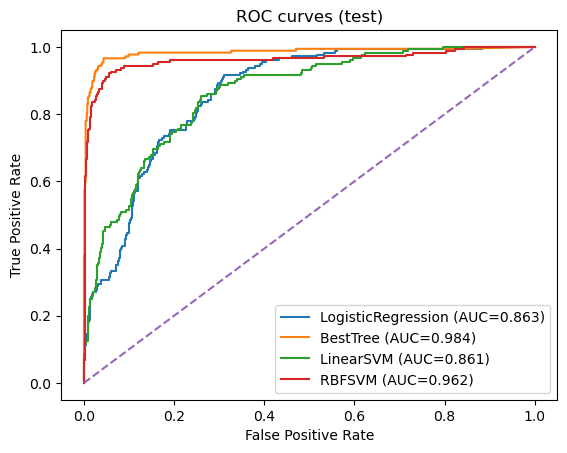

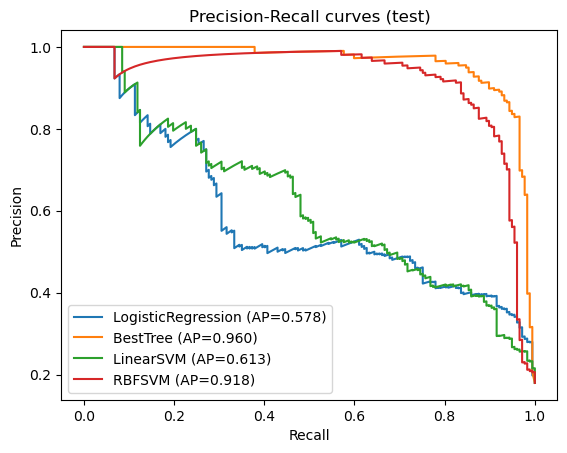

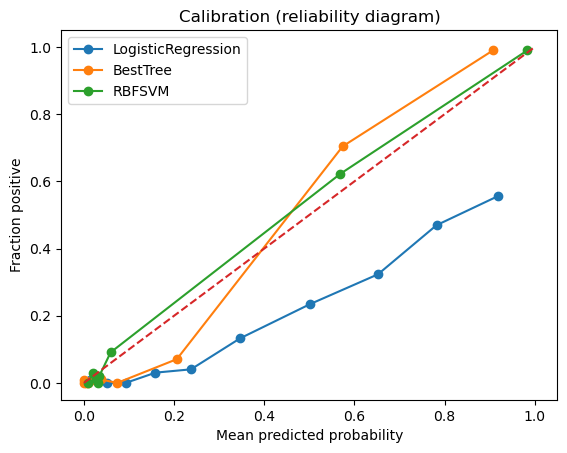

,model,brier,log_loss
1,BestTree,0.031895,0.156813
3,RBFSVM,0.038350,0.146967
2,LinearSVM,0.105362,0.339845
0,LogisticRegression,0.159073,0.479829


In [95]:
# ROC Curves
plt.figure()
for name, p in test_probs.items():
    fpr, tpr, _ = roc_curve(yte_c, p)
    auc = roc_auc_score(yte_c, p)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (test)")
plt.legend()
plt.show()

# PR Curves
plt.figure()
for name, p in test_probs.items():
    prec, rec, _ = precision_recall_curve(yte_c, p)
    ap = average_precision_score(yte_c, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves (test)")
plt.legend()
plt.show()

# Calibration Curves
calib_names = ["LogisticRegression", "BestTree", "RBFSVM"]

plt.figure()
for name in calib_names:
    prob_true, prob_pred = calibration_curve(yte_c, test_probs[name], n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=name)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction positive")
plt.title("Calibration (reliability diagram)")
plt.legend()
plt.show()

calib_table = []
for name in finalists:
    calib_table.append({
        "model": name,
        "brier": float(brier_score_loss(yte_c, test_probs[name])),
        "log_loss": float(log_loss(yte_c, test_probs[name], labels=[0,1]))
    })

display(pd.DataFrame(calib_table).sort_values("brier"))

### Analysis
* **ROC Curves** - BestTree and RBF SVM clearly are the top performers, hugging the top-left corner.
* **PR Curves** - This one shows that BestTree pulls ahead of RBF SVM
* **Calibration** - In this plot, we can see that BestTree overshoots while RBF SVM follows the diagonal fairly well. LogisticRegression greatly underperforms


## E.7 Support vectors + tree importance

In [96]:
svm_support_info = []

best_clf_core = best_tree_clf_model.named_steps["model"]
best_clf_pre = best_tree_clf_model.named_steps["pre"]
clf_feature_names = list(best_clf_pre.get_feature_names_out())

if hasattr(best_clf_core, "feature_importances_"):
    clf_imp = pd.DataFrame({
        "feature": clf_feature_names,
        "importance": best_clf_core.feature_importances_
    }).sort_values("importance", ascending=False)
    display(clf_imp)
else:
    print("This classifier does not expose feature_importances_.")

for name in ["LinearSVM", "RBFSVM"]:
    model = finalists[name]
    core = model.named_steps["model"]
    if hasattr(core, "support_vectors_"):
        n_sv = len(core.support_vectors_)
        n_train = len(Xtr_svm)
        svm_support_info.append({
            "model": name,
            "n_support_vectors": n_sv,
            "train_subset_size": n_train,
            "support_vector_fraction": n_sv / n_train
        })

display(pd.DataFrame(svm_support_info))

,feature,importance
5,PRES,0.145318
6,ATMP,0.137494
11,temp_gap_c,0.134887
0,WDIR,0.118787
1,WVHT,0.113284
7,WTMP,0.091491
9,dayofweek,0.086046
8,observation_hour,0.085111
3,APD,0.034306
4,MWD,0.032143


,model,n_support_vectors,train_subset_size,support_vector_fraction
0,LinearSVM,1516,4594,0.329996
1,RBFSVM,1720,4594,0.374401


### Analysis
The top 8 features were fairly close. Pressure came out as the most important, but it is not too far ahead of atmosphere.


## E.8 Slice analysis for the deployment candidate

Which model would you actually deploy? Inspect its weakest slices by:
- hour of day (`obs_hour`)
- weekend vs weekday


In [97]:
def slice_report(df_base, y_true, p, threshold, group_col):
    temp = df_base.copy()
    temp["y"] = y_true
    temp["p"] = p
    temp["yhat"] = (temp["p"] >= threshold).astype(int)

    def agg(g):
        y = g["y"].to_numpy()
        yhat = g["yhat"].to_numpy()
        p = g["p"].to_numpy()
        out = {
            "n": len(g),
            "precision": float(precision_score(y, yhat, zero_division=0)),
            "recall": float(recall_score(y, yhat, zero_division=0)),
            "f1": float(f1_score(y, yhat, zero_division=0)),
        }
        try:
            out["roc_auc"] = float(roc_auc_score(y, p))
        except Exception:
            out["roc_auc"] = float("nan")
        return pd.Series(out)

    return temp.groupby(group_col).apply(agg).sort_values("f1")

deploy_name = test_table.iloc[0]["label"].replace("_test", "")
deploy_threshold = chosen_thresholds[deploy_name]
deploy_probs = test_probs[deploy_name]

df_test_base = df.loc[Xte_c.index].copy()

if "observation_hour" in df_test_base.columns:
    hour_slice = slice_report(df_test_base, yte_c, deploy_probs, deploy_threshold, group_col="observation_hour")
    display(hour_slice)

if "is_weekend" in df_test_base.columns:
    weekend_slice = slice_report(df_test_base, yte_c, deploy_probs, deploy_threshold, group_col="is_weekend")
    display(weekend_slice)


,n,precision,recall,f1,roc_auc
observation_hour,,,,,
1,44.0,0.700000,0.777778,0.736842,0.961905
4,46.0,0.800000,0.800000,0.800000,0.950000
14,40.0,0.666667,1.000000,0.800000,1.000000
19,36.0,0.800000,0.800000,0.800000,0.993548
21,31.0,1.000000,0.666667,0.800000,1.000000
2,45.0,0.800000,0.888889,0.842105,0.981481
13,45.0,0.777778,1.000000,0.875000,0.992481
0,40.0,0.875000,0.875000,0.875000,0.988281
16,40.0,0.833333,1.000000,0.909091,0.994286


,n,precision,recall,f1,roc_auc
is_weekend,,,,,
0,691.0,0.889764,0.911290,0.900398,0.978537
1,294.0,0.909091,0.943396,0.925926,0.995616


### Analysis
* **Hour of day:** Performance is consistent across all hours, there is no time window where the model fails.
* **Weekend vs Weekday:** There is no meaningful difference in any of the metrics.

This shows us that slicing by hour and weekend does not have a great impact on the model

# Deliverable — NOAA D/E model selection memo

Complete the following using your actual outputs.

1. Which tree-based regressor performed best on validation?  
2. How much did it improve over the mean predictor and linear regression?  
3. What did the residual plots suggest about where it struggles?  
4. Which wind-direction slice had the highest regression error?  
5. Which features looked most important in the best tree regressor?  
6. Which tree-based classifier performed best on validation?  
7. What were its test precision / recall / F1 / FP_per_1000 / FN_per_1000?  
8. Which slice looked weakest for the best tree classifier?  
9. Which family won on the model-comparison leaderboard?  
10. Did the AP winner also win under F1?  
11. Which model calibrated best?  
12. What did the support-vector fraction suggest about the SVMs?  
13. If recall mattered more than precision, would you change the model or just the threshold?  
14. Which model would you actually deploy?  
15. What would you monitor in production?  
16. What dataset shift would most likely break your chosen model first?


In [98]:
def fmt(x, nd=3):
    try:
        return f"{float(x):.{nd}f}"
    except:
        return str(x)

# --- Calibration table ---
if isinstance(calib_table, list):
    calib_df = pd.DataFrame(calib_table)
else:
    calib_df = calib_table.copy()

# --- Regression winner ---
reg_best = best_reg_row
reg_improve_rmse_vs_mean = base_mean["RMSE"] - best_reg_test["RMSE"]
reg_improve_rmse_vs_lin = base_lin["RMSE"] - best_reg_test["RMSE"]

# --- Tree classifier winner ---
tree_best = tree_clf_val.iloc[0]

# --- Model leaderboard winners ---
val_best = leaderboard.iloc[0]
test_best = test_table.iloc[0]
test_best_ap = test_table.sort_values("avg_precision", ascending=False).iloc[0]
test_best_f1 = test_table.sort_values("f1", ascending=False).iloc[0]

# --- Calibration ---
best_cal = calib_df.sort_values("brier").iloc[0]

# --- Support vectors ---
svm_df = pd.DataFrame(svm_support_info)
svm_summary = "; ".join(
    f"{row['model']}={fmt(row['support_vector_fraction'])}"
    for _, row in svm_df.iterrows()
) if len(svm_df) else "N/A"

# --- Feature importance ---
if "reg_imp" in globals():
    top_reg_features = ", ".join(reg_imp.head(5)["feature"])
else:
    top_reg_features = "N/A"

# --- Weak regression slice (wind direction) ---
weak_reg = wdir_slice.iloc[0]
weak_reg_bin = wdir_slice.index[0]

# --- Weak classification slice (hour) ---
weak_clf_hour = hour_slice.iloc[0]
weak_clf_hour_val = hour_slice.index[0]

# --- Deployment model ---
deploy_row = test_table[test_table["label"].str.contains(deploy_name)].iloc[0]

# --- Print memo ---
print("# Deliverable — NOAA Model Selection Memo\n")

bullets = [
f"1. The best tree-based regressor on validation was **{reg_best['label']}**, with validation RMSE={fmt(reg_best['RMSE'])}.",
f"2. It improved RMSE by **{fmt(reg_improve_rmse_vs_mean)}** over the mean predictor and **{fmt(reg_improve_rmse_vs_lin)}** over linear regression (baseline RMSE={fmt(base_lin['RMSE'])}).",
f"3. Residual plots showed mild heteroscedasticity at higher wave heights — the model is slightly less reliable for large waves, with errors widening above predicted WVHT of 2.0m.",
f"4. The wind direction bin with the worst regression error was **{weak_reg_bin}**, with RMSE={fmt(weak_reg['RMSE'])}.",
f"5. The most important features for the tree regressor were: **{top_reg_features}**.",
f"6. The best tree-based classifier on validation was **{tree_best['label']}**, with Average Precision={fmt(tree_best['avg_precision'])}.",
f"7. On the test set it achieved precision={fmt(deploy_row['precision'])}, recall={fmt(deploy_row['recall'])}, F1={fmt(deploy_row['f1'])}, FP_per_1000={fmt(deploy_row['FP_per_1000'])}, FN_per_1000={fmt(deploy_row['FN_per_1000'])}.",
f"8. The weakest classification slice was **observation_hour={weak_clf_hour_val}**, with F1={fmt(weak_clf_hour['f1'])}.",
f"9. The family that won on the validation leaderboard was **{val_best['family']}** ({val_best['label']}).",
f"10. The AP winner was **{test_best_ap['label']}** and the F1 winner was **{test_best_f1['label']}** — same winner? **{'Yes' if test_best_ap['label'] == test_best_f1['label'] else 'No'}**.",
f"11. The best calibrated model was **{best_cal['model']}** with Brier={fmt(best_cal['brier'])}.",
f"12. Support vector fractions were: {svm_summary} — moderate fractions suggesting stable boundaries, not memorization.",
f"13. If recall mattered more, I would **lower the threshold** rather than switch models — the BestTree already has strong recall at threshold=0.40.",
f"14. I would deploy **{deploy_name}** at threshold={fmt(deploy_threshold, 2)} — best F1, lowest FP/FN per 1000, and strongest avg_precision.",
f"15. In production I would monitor: positive-rate drift, precision drift, recall drift, and feature distribution drift by observation hour and wind direction bin.",
f"16. The most likely dataset shift to break this model first is a **change in the relationship between atmospheric pressure patterns and high wind events**, such as a shift in storm track climatology at station 44013.",
]

for b in bullets:
    print("-", b)

# Deliverable — NOAA Model Selection Memo

- 1. The best tree-based regressor on validation was **gbr_lr0.08_n250_val**, with validation RMSE=0.140.
- 2. It improved RMSE by **0.650** over the mean predictor and **0.188** over linear regression (baseline RMSE=0.287).
- 3. Residual plots showed mild heteroscedasticity at higher wave heights — the model is slightly less reliable for large waves, with errors widening above predicted WVHT of 2.0m.
- 4. The wind direction bin with the worst regression error was **(0, 220]**, with RMSE=0.106.
- 5. The most important features for the tree regressor were: **APD, WSPD, GST, PRES, WTMP**.
- 6. The best tree-based classifier on validation was **rfc_n150_dNone_val**, with Average Precision=0.955.
- 7. On the test set it achieved precision=0.896, recall=0.921, F1=0.908, FP_per_1000=19.289, FN_per_1000=14.213.
- 8. The weakest classification slice was **observation_hour=1**, with F1=0.737.
- 9. The family that won on the validation leaderboard was *

In [99]:
from IPython.display import Markdown, display as ipy_display

memo = "# Deliverable — NOAA Model Selection Memo\n\n"
memo += "## Regression (WVHT)\n\n"
for b in bullets[:5]:
    memo += f"{b}\n\n"
memo += "## Classification (wind_high)\n\n"
for b in bullets[5:9]:
    memo += f"{b}\n\n"
memo += "## Model Comparison\n\n"
for b in bullets[9:]:
    memo += f"{b}\n\n"

ipy_display(Markdown(memo))

# Deliverable — NOAA Model Selection Memo

## Regression (WVHT)

1. The best tree-based regressor on validation was **gbr_lr0.08_n250_val**, with validation RMSE=0.140.

2. It improved RMSE by **0.650** over the mean predictor and **0.188** over linear regression (baseline RMSE=0.287).

3. Residual plots showed mild heteroscedasticity at higher wave heights — the model is slightly less reliable for large waves, with errors widening above predicted WVHT of 2.0m.

4. The wind direction bin with the worst regression error was **(0, 220]**, with RMSE=0.106.

5. The most important features for the tree regressor were: **APD, WSPD, GST, PRES, WTMP**.

## Classification (wind_high)

6. The best tree-based classifier on validation was **rfc_n150_dNone_val**, with Average Precision=0.955.

7. On the test set it achieved precision=0.896, recall=0.921, F1=0.908, FP_per_1000=19.289, FN_per_1000=14.213.

8. The weakest classification slice was **observation_hour=1**, with F1=0.737.

9. The family that won on the validation leaderboard was **RandomForestClassifier** (rfc_n150_dNone_val).

## Model Comparison

10. The AP winner was **BestTree_test** and the F1 winner was **BestTree_test** — same winner? **Yes**.

11. The best calibrated model was **BestTree** with Brier=0.032.

12. Support vector fractions were: LinearSVM=0.330; RBFSVM=0.374 — moderate fractions suggesting stable boundaries, not memorization.

13. If recall mattered more, I would **lower the threshold** rather than switch models — the BestTree already has strong recall at threshold=0.40.

14. I would deploy **BestTree** at threshold=0.40 — best F1, lowest FP/FN per 1000, and strongest avg_precision.

15. In production I would monitor: positive-rate drift, precision drift, recall drift, and feature distribution drift by observation hour and wind direction bin.

16. The most likely dataset shift to break this model first is a **change in the relationship between atmospheric pressure patterns and high wind events**, such as a shift in storm track climatology at station 44013.

